<a href="https://colab.research.google.com/drive/1-DBLyRSpO2Bs1k6PrVzQNdio-DejCGY6?usp=drive_link" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention

In [1]:
from torch import nn
from torch.nn import functional as F
from tqdm import tqdm

import torch
import math

In [2]:

#길이 3인 시퀀스 / 각 token이 4차원 벡터를 가짐
x = torch.tensor([
  [1.0, 0.0, 1.0, 0.0],
  [0.0, 2.0, 0.0, 2.0],
  [1.0, 1.0, 1.0, 1.0],
])
#가중치 행렬
w_query = torch.tensor([
  [1.0, 0.0, 1.0],
  [1.0, 0.0, 0.0],
  [0.0, 0.0, 1.0],
  [0.0, 1.0, 1.0]
])
w_key = torch.tensor([
  [0.0, 0.0, 1.0],
  [1.0, 1.0, 0.0],
  [0.0, 1.0, 0.0],
  [1.0, 1.0, 0.0]
])
w_value = torch.tensor([
  [0.0, 2.0, 0.0],
  [0.0, 3.0, 0.0],
  [1.0, 0.0, 3.0],
  [1.0, 1.0, 0.0]
])

In [3]:
#행렬곱을 통해 각 토큰의 K,Q,V 생성
keys = torch.matmul(x,w_key)
querys = torch.matmul(x,w_query)
values = torch.matmul(x,w_value)
print(keys)

tensor([[0., 1., 1.],
        [4., 4., 0.],
        [2., 3., 1.]])


In [4]:
attn_scores = torch.matmul(querys,keys.T)
attn_scores
#(token 개수, token 개수) => (3,3)
#행: 기준이 되는 query token
#열: 참고 대상 key token
#[i,j] => i번째 토큰이 j번째 토큰을 얼마나 볼지

tensor([[ 2.,  4.,  4.],
        [ 4., 16., 12.],
        [ 4., 12., 10.]])

In [5]:
import numpy as np
from torch.nn.functional import softmax
#정규화 -> softmax => 확률처럼 표현
key_dim_sqrt = np.sqrt(keys.shape[-1])
attn_scores_softmax = softmax(attn_scores / key_dim_sqrt, dim=-1)
attn_scores_softmax

tensor([[1.3613e-01, 4.3194e-01, 4.3194e-01],
        [8.9045e-04, 9.0884e-01, 9.0267e-02],
        [7.4449e-03, 7.5471e-01, 2.3785e-01]])

In [6]:
#value 가중합
weighted_values = torch.matmul(attn_scores_softmax,values)
weighted_values

tensor([[1.8639, 6.3194, 1.7042],
        [1.9991, 7.8141, 0.2735],
        [1.9926, 7.4796, 0.7359]])

# Seq2Seq


In this project we will be teaching a neural network to translate from
French to English.

::

    [KEY: > input, = target, < output]

    > il est en train de peindre un tableau .
    = he is painting a picture .
    < he is painting a picture .

    > pourquoi ne pas essayer ce vin delicieux ?
    = why not try that delicious wine ?
    < why not try that delicious wine ?

    > elle n est pas poete mais romanciere .
    = she is not a poet but a novelist .
    < she not not a poet but a novelist .

    > vous etes trop maigre .
    = you re too skinny .
    < you re all alone .


## Data preparation

In [7]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
SOS_token = 0
EOS_token = 1

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {} #단어 -> 인덱스
        self.word2count = {} #단어 등장 횟수
        self.index2word = {0: "SOS", 1: "EOS"} #인덱스 -> 단어
        self.n_words = 2  # Count SOS and EOS , 전체 vocab 크기

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [9]:
# Turn a Unicode string to plain ASCII, thanks to
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s): # é → e
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

In [10]:
def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")

    # Read the file and split into lines
    lines = open('/content/eng-fra.txt').\
        read().strip().split('\n')

    # Split every line into pairs(eng, fra) and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs
    #번역 모델은 결국 (입력문장, 출력문장) 쌍을 학습하는 supervised learning 문제

In [11]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

#예제용으로 비교적 단순한 문장만 사용
def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH and \
        p[1].startswith(eng_prefixes)


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [12]:
#eng-fra.txt 파일 업로드 필요
import re
def prepareData(lang1, lang2, reverse=False):
    #데이터 읽기 -> normalize -> filter -> vocab 구축 -> 샘플 출력
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
print(random.choice(pairs))

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
['vous etes productifs', 'you re productive']


## Seq2Seq Model

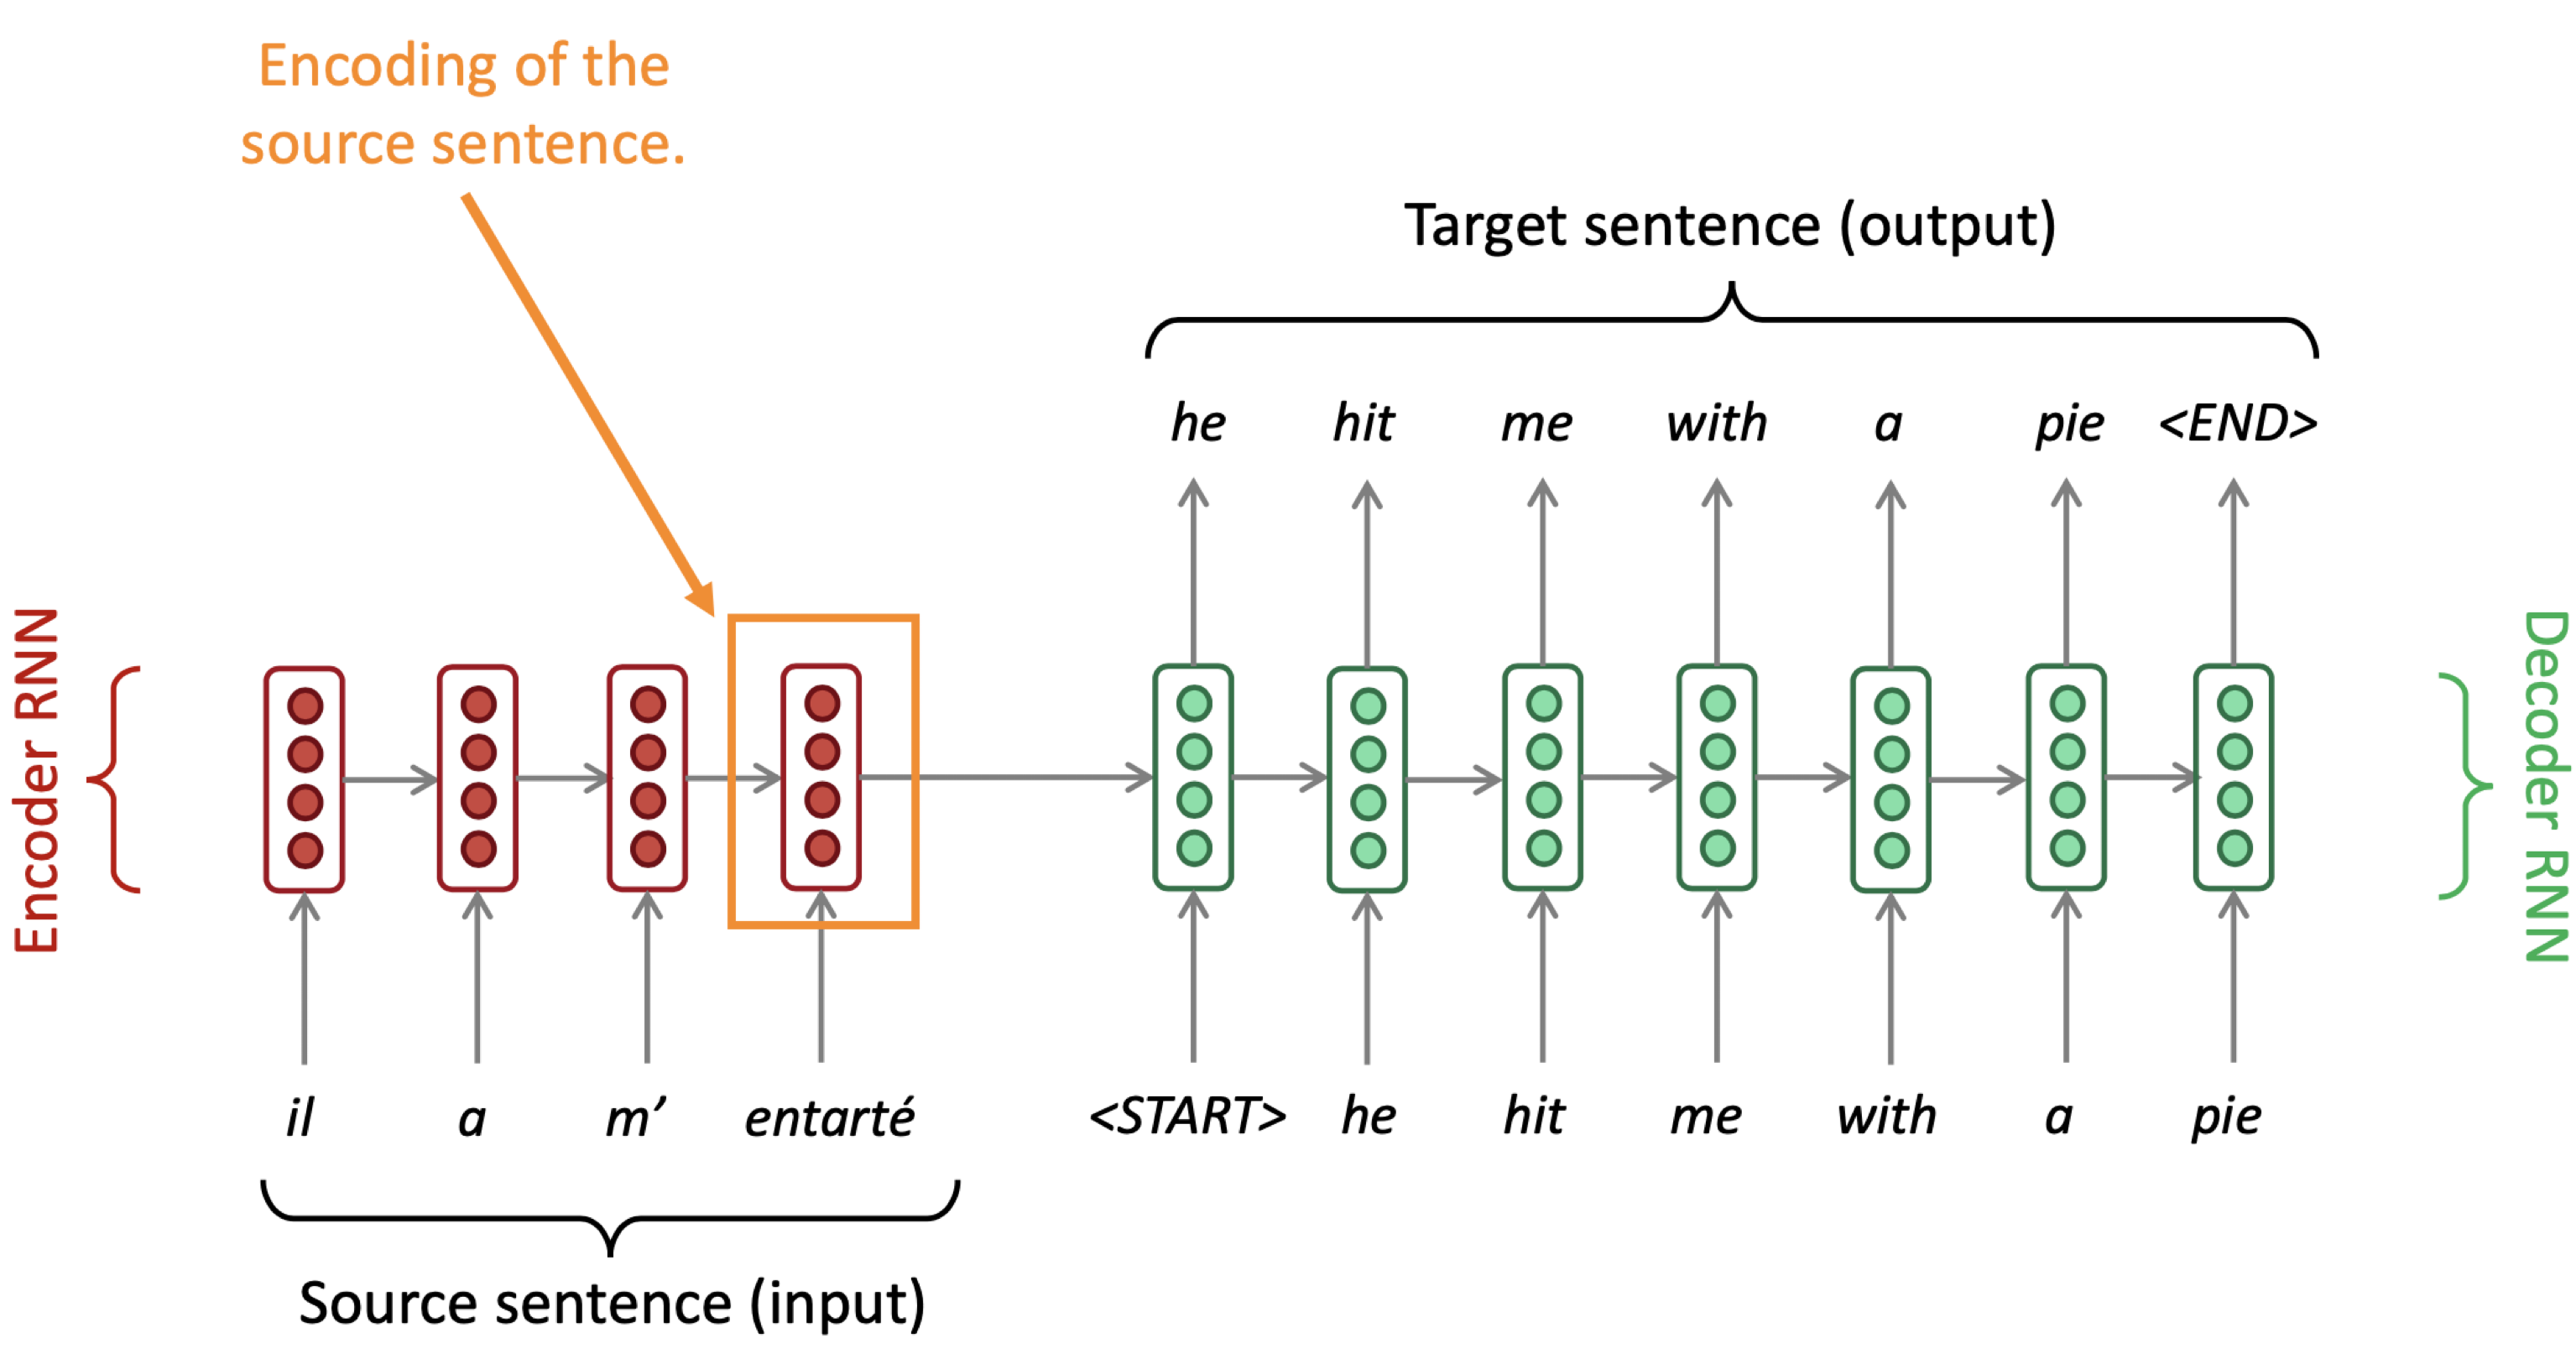

### Encoder

In [13]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True) #RNN 계열 model
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input)) #단어 인덱스를 dense vector로 변환
        output, hidden = self.gru(embedded)
        return output, hidden

### Decoder

In [14]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) #(batch_size,) -> (batch_size,1)
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach() #(batch_size,1,1) -> (batch_size,1)
                # detach from history as input (gradient graph 끊어주기 / 상수처럼 사용)

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

### Attention Decoder

In [15]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        #query: (batch_size, 1, hidden_size)
        #keys: (batch_size, seq_len, hidden_size)
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        #scores: (batch_size, seq_len, 1)
        scores = scores.squeeze(2).unsqueeze(1) #->(batch_size, seq_len)->(batch_size,1,seq_len)

        weights = F.softmax(scores, dim=-1) #seq_len 방향으로 softmax
        context = torch.bmm(weights, keys) #(batch_size, 1, seq_len), (batch_size, seq_len, hidden_size) -> (batch_size, 1, hidden_size)

        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token) #shape (batch_size,1)
        #seq2seq의 기본 아이디어: decoder의 초기 hidden state를 encoder의 마지막 hidden state로 설정
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) #(batch_size,) -> (batch_size,1)
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach() #(batch_size,1,1) -> (batch_size,1)
                # detach from history as input (gradient graph 끊어주기 / 상수처럼 사용)

        decoder_outputs = torch.cat(decoder_outputs, dim=1) #step마다 저장한 출력들을 시간축으로 이어붙임
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input)) #(batch_size,1)->(batch_size,1,hidden_size)
        #dropdout: embedding vector 일부를 랜덤하게 꺼서 regularization

        query = hidden.permute(1, 0, 2) #decoder hidden(1(layer),batch_size,hidden_size) -> attention query(batch_size,1,hidden_size)
        context, attn_weights = self.attention(query, encoder_outputs)#value, weight
        input_gru = torch.cat((embedded, context), dim=2)#(batch_size,1,2*hidden_size)

        output, hidden = self.gru(input_gru, hidden)
        #output: (batch_size, 1, hidden_size)
        #hidden: (1, batch_size, hidden_size)
        output = self.out(output)
        #(batch_size, 1, output_size)

        return output, hidden, attn_weights

## Training

In [16]:
import time
import math

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepareData('eng', 'fra', True)

    n = len(pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    train_data = TensorDataset(torch.LongTensor(input_ids).to(device),
                               torch.LongTensor(target_ids).to(device))

    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
    return input_lang, output_lang, train_dataloader

In [17]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion):

    total_loss = 0
    for data in dataloader: #batch 단위
        input_tensor, target_tensor = data

        #gradient 초기화
        #TODO
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        #encoder, decoder
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        #decoder output = (batchsize, seq_len, vocab_size)
        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)), #(batch_size*seq_len, vocab_size)
            #TODO #(batch_size, seq_len) -> (batch_size * seq_len)
            target_tensor.view(-1)
        )
        #TODO
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [18]:
def train(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001,
               print_every=100, plot_every=100):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    #optimizer, loss함수 설정
    #TODO
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)

    criterion = nn.NLLLoss() #negative log likelihood loss (decoder 출력이 log probability라서 적합한 loss)

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs),
                                        epoch, epoch / n_epochs * 100, print_loss_avg))

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

In [19]:
import matplotlib.pyplot as plt
plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)

In [20]:

def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad(): #graident를 계산하지 않겠다!!!
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze() #불필요한 차원 제거

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>') #문장 끝이 나오면 종료
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn

In [21]:

def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

In [ ]:
hidden_size = 128
batch_size = 32

input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

attention_encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
attention_decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

n_epochs = 200 #-->100
train(train_dataloader, attention_encoder, attention_decoder, n_epochs, print_every=1, plot_every=1)

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
0m 8s (- 27m 17s) (1 0%) 2.4760
0m 16s (- 27m 42s) (2 1%) 1.6532
0m 25s (- 27m 48s) (3 1%) 1.3818
0m 33s (- 27m 25s) (4 2%) 1.1831
0m 41s (- 27m 13s) (5 2%) 1.0246
0m 50s (- 27m 10s) (6 3%) 0.8912
0m 59s (- 27m 12s) (7 3%) 0.7770
1m 7s (- 26m 48s) (8 4%) 0.6810
1m 15s (- 26m 44s) (9 4%) 0.5949
1m 24s (- 26m 42s) (10 5%) 0.5233
1m 32s (- 26m 26s) (11 5%) 0.4601
1m 40s (- 26m 21s) (12 6%) 0.4053
1m 49s (- 26m 18s) (13 6%) 0.3573
1m 57s (- 26m 2s) (14 7%) 0.3188
2m 6s (- 25m 59s) (15 7%) 0.2814
2m 15s (- 25m 54s) (16 8%) 0.2496
2m 23s (- 25m 39s) (17 8%) 0.2243
2m 31s (- 25m 33s) (18 9%) 0.2023
2m 40s (- 25m 24s) (19 9%) 0.1832
2m 47s (- 25m 10s) (20 10%) 0.1653
2m 56s (- 25m 2s) (21 10%) 0.1508
3m 4s (- 24m 55s) (22 11%) 0.1365
3m 12s (- 24m 45s) (23 11%) 0.1271
3m 21s (- 24m 38s) (24 12%) 0.1177
3m 30s (- 24m 33s) (25 12%) 0.1083
3m 38s (- 24m 25s) (26 13%) 0.10

In [ ]:

attention_encoder.eval()
attention_decoder.eval()
evaluateRandomly(attention_encoder, attention_decoder)

In [ ]:

hidden_size = 128
batch_size = 32

input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

n_epochs = 2 #-->100
train(train_dataloader, encoder, decoder, n_epochs, print_every=1, plot_every=1)

In [ ]:

encoder.eval()
decoder.eval()
evaluateRandomly(encoder, decoder)

### Visualize attention

In [26]:
%matplotlib inline

input = il n est pas aussi grand que son pere
output = he is not as as as as as as as


/tmp/ipykernel_2270/2058683575.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_2270/2058683575.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


<Figure size 640x480 with 0 Axes>

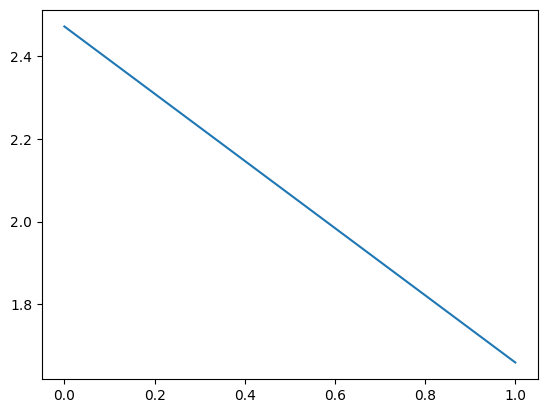

<Figure size 640x480 with 0 Axes>

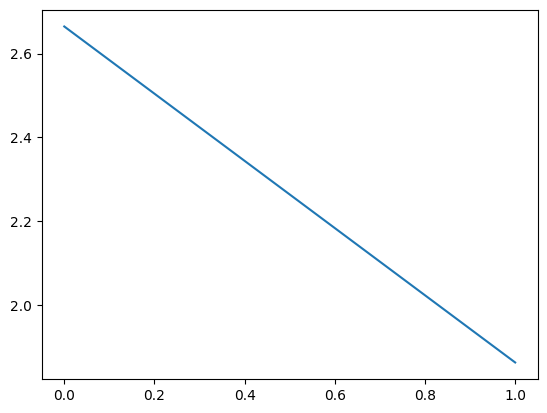

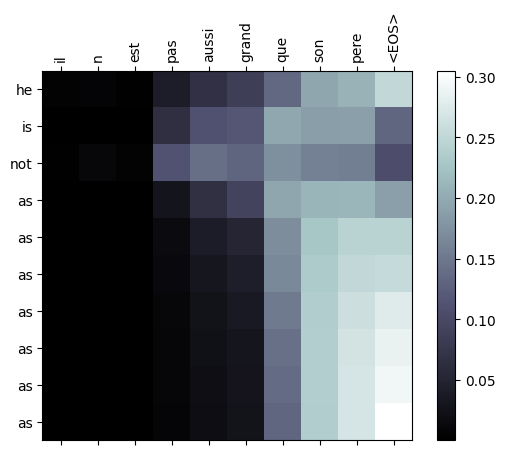

input = je suis trop fatigue pour conduire
output = i m sure i am for the one who trained


/tmp/ipykernel_2270/2058683575.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_2270/2058683575.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


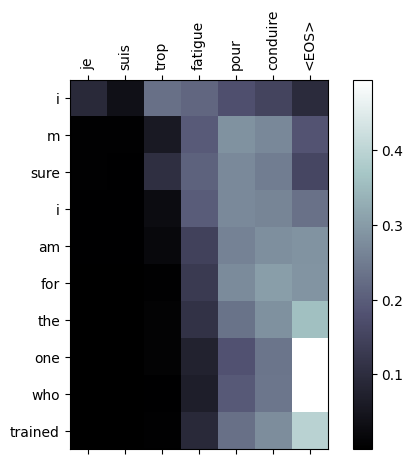

input = je suis desole si c est une question idiote
output = i m sorry i don t recognize you <EOS>


/tmp/ipykernel_2270/2058683575.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_2270/2058683575.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


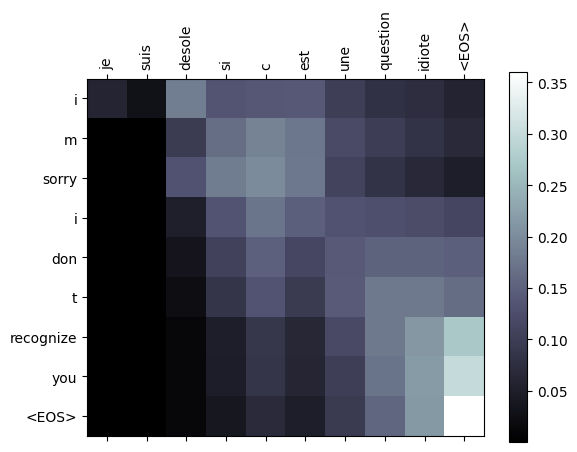

input = je suis reellement fiere de vous
output = i m sorry i don t you <EOS>


/tmp/ipykernel_2270/2058683575.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_2270/2058683575.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


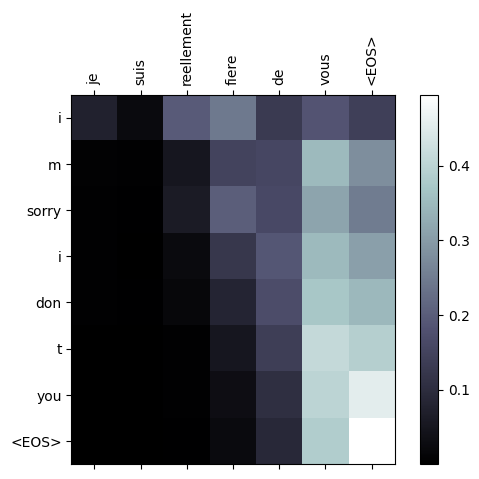

In [27]:
def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + input_sentence.split(' ') +
                       ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(attention_encoder, attention_decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :])


evaluateAndShowAttention('il n est pas aussi grand que son pere')

evaluateAndShowAttention('je suis trop fatigue pour conduire')

evaluateAndShowAttention('je suis desole si c est une question idiote')

evaluateAndShowAttention('je suis reellement fiere de vous')

# Transformer

## Self-Attention

In [ ]:
from torch import nn
from torch.nn import functional as F
from tqdm import tqdm

import torch
import math

In [ ]:

x = torch.tensor([
  [1.0, 0.0, 1.0, 0.0],
  [0.0, 2.0, 0.0, 2.0],
  [1.0, 1.0, 1.0, 1.0],
])
w_query = torch.tensor([
  [1.0, 0.0, 1.0],
  [1.0, 0.0, 0.0],
  [0.0, 0.0, 1.0],
  [0.0, 1.0, 1.0]
])
w_key = torch.tensor([
  [0.0, 0.0, 1.0],
  [1.0, 1.0, 0.0],
  [0.0, 1.0, 0.0],
  [1.0, 1.0, 0.0]
])
w_value = torch.tensor([
  [0.0, 2.0, 0.0],
  [0.0, 3.0, 0.0],
  [1.0, 0.0, 3.0],
  [1.0, 1.0, 0.0]
])

In [ ]:
keys = torch.matmul(x, w_key)
querys = torch.matmul(x, w_query)
values = torch.matmul(x, w_value)

In [ ]:
attn_scores = torch.matmul(querys, keys.T)
attn_scores

tensor([[ 2.,  4.,  4.],
        [ 4., 16., 12.],
        [ 4., 12., 10.]])

In [ ]:
import numpy as np
from torch.nn.functional import softmax
key_dim_sqrt = np.sqrt(keys.shape[-1])
attn_scores_softmax = softmax(attn_scores / key_dim_sqrt, dim=-1)
attn_scores_softmax

tensor([[1.3613e-01, 4.3194e-01, 4.3194e-01],
        [8.9045e-04, 9.0884e-01, 9.0267e-02],
        [7.4449e-03, 7.5471e-01, 2.3785e-01]])

In [ ]:
weighted_values = torch.matmul(attn_scores_softmax, values)
weighted_values

tensor([[1.8639, 6.3194, 1.7042],
        [1.9991, 7.8141, 0.2735],
        [1.9926, 7.4796, 0.7359]])

## Multi-head Attention

In [ ]:
from torch import nn
from torch.nn import functional as F
from tqdm import tqdm

import torch
import math

In [ ]:
pad_id = 0
vocab_size = 100

data = [
  [62, 13, 47, 39, 78, 33, 56, 13, 39, 29, 44, 86, 71, 36, 18, 75],
  [60, 96, 51, 32, 90],
  [35, 45, 48, 65, 91, 99, 92, 10, 3, 21, 54],
  [75, 51],
  [66, 88, 98, 47],
  [21, 39, 10, 64, 21],
  [98],
  [77, 65, 51, 77, 19, 15, 35, 19, 23, 97, 50, 46, 53, 42, 45, 91, 66, 3, 43, 10],
  [70, 64, 98, 25, 99, 53, 4, 13, 69, 62, 66, 76, 15, 75, 45, 34],
  [20, 64, 81, 35, 76, 85, 1, 62, 8, 45, 99, 77, 19, 43]
]

In [ ]:
def padding(data):
  max_len = len(max(data, key=len))
  print(f"Maximum sequence length: {max_len}")

  for i, seq in enumerate(tqdm(data)):
    if len(seq) < max_len:
      data[i] = seq + [pad_id] * (max_len - len(seq))

  return data, max_len

In [ ]:
data, max_len = padding(data)

Maximum sequence length: 20


100%|██████████| 10/10 [00:00<00:00, 49636.73it/s]


In [ ]:
data

[[62, 13, 47, 39, 78, 33, 56, 13, 39, 29, 44, 86, 71, 36, 18, 75, 0, 0, 0, 0],
 [60, 96, 51, 32, 90, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [35, 45, 48, 65, 91, 99, 92, 10, 3, 21, 54, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [75, 51, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [66, 88, 98, 47, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [21, 39, 10, 64, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [98, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [77,
  65,
  51,
  77,
  19,
  15,
  35,
  19,
  23,
  97,
  50,
  46,
  53,
  42,
  45,
  91,
  66,
  3,
  43,
  10],
 [70, 64, 98, 25, 99, 53, 4, 13, 69, 62, 66, 76, 15, 75, 45, 34, 0, 0, 0, 0],
 [20, 64, 81, 35, 76, 85, 1, 62, 8, 45, 99, 77, 19, 43, 0, 0, 0, 0, 0, 0]]

In [ ]:
d_model = 512  # model의 hidden size
num_heads = 8  # head의 개수

In [ ]:
embedding = nn.Embedding(vocab_size, d_model)

# B: batch size, L: maximum sequence length
batch = torch.LongTensor(data)  # (B, L)
batch_emb = embedding(batch)  # (B, L, d_model)

In [ ]:
print(batch_emb)
print(batch_emb.shape)

tensor([[[-1.3387e-01, -2.3192e+00,  3.8141e-01,  ..., -3.8542e-02,
          -3.4268e-01,  7.8136e-01],
         [ 5.9086e-01,  1.2711e+00,  5.0793e-01,  ...,  1.0640e-01,
          -7.3732e-01, -7.9660e-02],
         [-2.0998e+00, -1.7717e-01, -4.3869e-01,  ...,  6.1699e-01,
          -5.6490e-01,  2.4208e-01],
         ...,
         [ 4.2713e-01,  1.2484e+00, -1.4274e+00,  ...,  1.8932e+00,
           1.9896e+00,  1.3735e+00],
         [ 4.2713e-01,  1.2484e+00, -1.4274e+00,  ...,  1.8932e+00,
           1.9896e+00,  1.3735e+00],
         [ 4.2713e-01,  1.2484e+00, -1.4274e+00,  ...,  1.8932e+00,
           1.9896e+00,  1.3735e+00]],

        [[-1.1917e+00,  6.4460e-01,  7.1422e-02,  ...,  3.9237e-01,
           6.3046e-02,  1.1097e+00],
         [-5.0992e-01,  1.5382e-01,  2.0639e-02,  ..., -8.5196e-01,
           1.0519e+00, -4.1603e-01],
         [ 5.4332e-01, -1.5856e+00,  2.9154e-01,  ...,  4.0422e-01,
           1.2206e+00, -7.2621e-01],
         ...,
         [ 4.2713e-01,  1

In [ ]:
w_q = nn.Linear(d_model, d_model)
w_k = nn.Linear(d_model, d_model)
w_v = nn.Linear(d_model, d_model)

In [ ]:
w_0 = nn.Linear(d_model, d_model)

In [ ]:
q = w_q(batch_emb)  # (B, L, d_model)
k = w_k(batch_emb)  # (B, L, d_model)
v = w_v(batch_emb)  # (B, L, d_model)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([10, 20, 512])
torch.Size([10, 20, 512])
torch.Size([10, 20, 512])


In [ ]:
batch_size = q.shape[0]
d_k = d_model // num_heads

q = q.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
k = k.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
v = v.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([10, 20, 8, 64])
torch.Size([10, 20, 8, 64])
torch.Size([10, 20, 8, 64])


In [ ]:
q = q.transpose(1, 2)  # (B, num_heads, L, d_k)
k = k.transpose(1, 2)  # (B, num_heads, L, d_k)
v = v.transpose(1, 2)  # (B, num_heads, L, d_k)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([10, 8, 20, 64])
torch.Size([10, 8, 20, 64])
torch.Size([10, 8, 20, 64])


In [ ]:
attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, L, L)
attn_dists = F.softmax(attn_scores, dim=-1)  # (B, num_heads, L, L)

print(attn_dists)
print(attn_dists.shape)

tensor([[[[0.0800, 0.0528, 0.0446,  ..., 0.0298, 0.0298, 0.0298],
          [0.0461, 0.0451, 0.0552,  ..., 0.0740, 0.0740, 0.0740],
          [0.0589, 0.0548, 0.0743,  ..., 0.0380, 0.0380, 0.0380],
          ...,
          [0.1015, 0.0647, 0.0312,  ..., 0.0521, 0.0521, 0.0521],
          [0.1015, 0.0647, 0.0312,  ..., 0.0521, 0.0521, 0.0521],
          [0.1015, 0.0647, 0.0312,  ..., 0.0521, 0.0521, 0.0521]],

         [[0.0270, 0.0439, 0.0256,  ..., 0.0652, 0.0652, 0.0652],
          [0.0347, 0.0392, 0.0481,  ..., 0.0486, 0.0486, 0.0486],
          [0.0819, 0.0297, 0.1305,  ..., 0.0532, 0.0532, 0.0532],
          ...,
          [0.0611, 0.0403, 0.0575,  ..., 0.0567, 0.0567, 0.0567],
          [0.0611, 0.0403, 0.0575,  ..., 0.0567, 0.0567, 0.0567],
          [0.0611, 0.0403, 0.0575,  ..., 0.0567, 0.0567, 0.0567]],

         [[0.0541, 0.0418, 0.0554,  ..., 0.0383, 0.0383, 0.0383],
          [0.0571, 0.0569, 0.0859,  ..., 0.0420, 0.0420, 0.0420],
          [0.0510, 0.0291, 0.0508,  ..., 0

In [ ]:
attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, L, d_k)

print(attn_values.shape)

torch.Size([10, 8, 20, 64])


In [ ]:
attn_values = attn_values.transpose(1, 2)  # (B, L, num_heads, d_k)
attn_values = attn_values.contiguous().view(batch_size, -1, d_model)  # (B, L, d_model)

print(attn_values.shape)

torch.Size([10, 20, 512])


In [ ]:
outputs = w_0(attn_values)

print(outputs)
print(outputs.shape)

tensor([[[-1.2724e-01,  5.2774e-02,  1.6910e-01,  ..., -1.1366e-01,
           3.4922e-02,  5.1663e-02],
         [-7.5145e-02,  3.9241e-02,  1.7482e-01,  ..., -1.4713e-01,
          -2.8400e-03,  9.4481e-02],
         [-5.9493e-02,  4.7503e-02,  1.5835e-01,  ..., -9.0968e-02,
          -9.0063e-03,  1.4740e-03],
         ...,
         [-8.8893e-02,  1.7327e-02,  1.4432e-01,  ..., -1.2473e-01,
           1.6631e-02,  3.5991e-02],
         [-8.8893e-02,  1.7327e-02,  1.4432e-01,  ..., -1.2473e-01,
           1.6631e-02,  3.5991e-02],
         [-8.8893e-02,  1.7327e-02,  1.4432e-01,  ..., -1.2473e-01,
           1.6631e-02,  3.5991e-02]],

        [[-2.8014e-03, -1.2303e-01,  1.0892e-01,  ..., -1.0095e-02,
           1.0939e-01, -3.1414e-02],
         [ 6.6791e-03, -1.5308e-01,  1.2124e-01,  ..., -1.3698e-02,
           9.6128e-02, -4.4301e-02],
         [ 6.4576e-04, -1.6558e-01,  1.3038e-01,  ..., -2.1884e-02,
           3.5363e-02, -5.1196e-02],
         ...,
         [ 1.6467e-02, -1

In [ ]:
class MultiheadAttention(nn.Module):
  def __init__(self):
    super(MultiheadAttention, self).__init__()

    # Q, K, V learnable matrices
    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)

    # Linear transformation for concatenated outputs
    self.w_0 = nn.Linear(d_model, d_model)

  def forward(self, q, k, v):
    batch_size = q.shape[0]

    q = self.w_q(q)  # (B, L, d_model)
    k = self.w_k(k)  # (B, L, d_model)
    v = self.w_v(v)  # (B, L, d_model)

    q = q.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
    k = k.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
    v = v.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)

    q = q.transpose(1, 2)  # (B, num_heads, L, d_k)
    k = k.transpose(1, 2)  # (B, num_heads, L, d_k)
    v = v.transpose(1, 2)  # (B, num_heads, L, d_k)

    attn_values = self.self_attention(q, k, v)  # (B, num_heads, L, d_k)
    attn_values = attn_values.transpose(1, 2).contiguous().view(batch_size, -1, d_model)  # (B, L, num_heads, d_k) => (B, L, d_model)

    return self.w_0(attn_values)

  def self_attention(self, q, k, v):
    attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, L, L)
    attn_dists = F.softmax(attn_scores, dim=-1)  # (B, num_heads, L, L)

    attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, L, d_k)

    return attn_values

In [ ]:
multihead_attn = MultiheadAttention()

outputs = multihead_attn(batch_emb, batch_emb, batch_emb)  # (B, L, d_model)

In [ ]:
print(outputs)
print(outputs.shape)

tensor([[[-1.8462e-01,  7.5854e-02,  1.9004e-01,  ...,  2.1190e-02,
          -3.7217e-02,  1.1341e-01],
         [-1.7992e-01,  8.0953e-02,  2.0338e-01,  ..., -1.4551e-02,
          -6.5287e-02,  1.1189e-01],
         [-1.0805e-01,  6.7647e-02,  1.4434e-01,  ...,  1.2071e-02,
          -8.6454e-02,  1.6004e-01],
         ...,
         [-1.2637e-01,  1.1056e-01,  2.0179e-01,  ...,  4.1398e-02,
          -4.3079e-02,  9.5825e-02],
         [-1.2637e-01,  1.1056e-01,  2.0179e-01,  ...,  4.1398e-02,
          -4.3079e-02,  9.5825e-02],
         [-1.2637e-01,  1.1056e-01,  2.0179e-01,  ...,  4.1398e-02,
          -4.3079e-02,  9.5825e-02]],

        [[-4.5609e-01,  6.0985e-02,  2.7422e-01,  ...,  1.8227e-01,
          -2.2477e-04,  1.9125e-01],
         [-4.8799e-01,  1.2385e-01,  3.7657e-01,  ...,  1.3895e-01,
          -3.8368e-02,  1.6875e-01],
         [-4.5693e-01,  9.0354e-02,  3.0343e-01,  ...,  1.7720e-01,
           2.2439e-03,  1.6502e-01],
         ...,
         [-5.1973e-01,  1

## Masked Multi-head Attention

In [ ]:
from torch import nn
from torch.nn import functional as F
from tqdm import tqdm

import torch
import math

In [ ]:
pad_id = 0
vocab_size = 100


# 단어를 토크나이저를 사용해 단어 인덱스로 변환한 상태
data = [
  [62, 13, 47, 39, 78, 33, 56, 13],
  [60, 96, 51, 32, 90],
  [35, 45, 48, 65, 91, 99, 92, 10, 3, 21],
  [66, 88, 98, 47],
  [77, 65, 51, 77, 19, 15, 35, 19, 23]
]

In [ ]:
def padding(data):
    # 배치안의 문장의 길이는 각각 다르기 때문에 모델의 입력으로 사용하기 위해서는 입력길이를 모두 똑같이 만들어 줘야함
    max_len = len(max(data, key=len))
    print(f"Maximum sequence length: {max_len}")

    for i, seq in enumerate(tqdm(data)):
        if len(seq) < max_len:
            data[i] = seq + [pad_id] * (max_len - len(seq))

    return data, max_len

In [ ]:
data, max_len = padding(data)

Maximum sequence length: 10


100%|██████████| 5/5 [00:00<00:00, 60262.99it/s]


In [ ]:
d_model = 8  # model의 hidden size
num_heads = 2  # head의 개수
inf = 1e12

In [ ]:
embedding = nn.Embedding(vocab_size, d_model)

# B: batch size, L: maximum sequence length
batch = torch.LongTensor(data)  # (B, L)
batch_emb = embedding(batch)  # (B, L, d_model)

In [ ]:
print(batch_emb)
print(batch_emb.shape)

tensor([[[-5.7383e-01, -2.8224e-01,  1.6611e+00, -1.2854e+00,  4.7086e-01,
          -3.0677e-01,  1.6439e+00, -2.1844e+00],
         [ 1.7815e+00, -1.9965e+00,  9.4091e-01,  8.1428e-01,  7.4743e-01,
           5.0767e-01, -1.6518e+00,  6.2209e-01],
         [-1.2631e+00, -1.4950e+00, -3.5383e-01,  1.1645e+00,  8.8049e-02,
           2.0943e+00,  4.4949e-01, -2.8266e-01],
         [ 9.4926e-01,  2.2929e+00, -1.2609e+00, -2.1745e-01, -1.1590e+00,
          -2.2970e-03, -8.0373e-01, -2.9650e-02],
         [-8.2719e-01, -5.5936e-02, -7.0471e-01, -5.9392e-01, -1.1912e+00,
          -3.9913e-01,  1.7285e-01, -1.1959e+00],
         [-6.5731e-01, -1.2733e+00,  1.3686e+00, -3.6642e-01, -1.5656e+00,
           9.8602e-02, -1.9789e-01,  1.0425e+00],
         [ 1.0360e+00,  8.7579e-01, -9.6065e-01,  8.9669e-01, -1.0164e+00,
          -4.8481e-02, -7.3709e-02, -1.1360e+00],
         [ 1.7815e+00, -1.9965e+00,  9.4091e-01,  8.1428e-01,  7.4743e-01,
           5.0767e-01, -1.6518e+00,  6.2209e-01],


In [ ]:
padding_mask = (batch != pad_id).unsqueeze(1)  # (B, 1, L)

print(padding_mask)
print(padding_mask.shape)

tensor([[[ True,  True,  True,  True,  True,  True,  True,  True, False, False]],

        [[ True,  True,  True,  True,  True, False, False, False, False, False]],

        [[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True]],

        [[ True,  True,  True,  True, False, False, False, False, False, False]],

        [[ True,  True,  True,  True,  True,  True,  True,  True,  True, False]]])
torch.Size([5, 1, 10])


In [ ]:
nopeak_mask = torch.ones([1, max_len, max_len], dtype=torch.bool)  # (1, L, L)
nopeak_mask = torch.tril(nopeak_mask)  # (1, L, L)

print(nopeak_mask)
print(nopeak_mask.shape)

tensor([[[ True, False, False, False, False, False, False, False, False, False],
         [ True,  True, False, False, False, False, False, False, False, False],
         [ True,  True,  True, False, False, False, False, False, False, False],
         [ True,  True,  True,  True, False, False, False, False, False, False],
         [ True,  True,  True,  True,  True, False, False, False, False, False],
         [ True,  True,  True,  True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True]]])
torch.Size([1, 10, 10])


In [ ]:
mask = padding_mask & nopeak_mask  # (B, L, L)

print(mask)
print(mask.shape)

tensor([[[ True, False, False, False, False, False, False, False, False, False],
         [ True,  True, False, False, False, False, False, False, False, False],
         [ True,  True,  True, False, False, False, False, False, False, False],
         [ True,  True,  True,  True, False, False, False, False, False, False],
         [ True,  True,  True,  True,  True, False, False, False, False, False],
         [ True,  True,  True,  True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False, False]],

        [[ True, False, False, False, False, False, False, False, False, False],
         [ True,  True, False, False, False, False, False, False, False, False],
         [ True,  True,  T

In [ ]:
w_q = nn.Linear(d_model, d_model)
w_k = nn.Linear(d_model, d_model)
w_v = nn.Linear(d_model, d_model)

w_0 = nn.Linear(d_model, d_model)

In [ ]:
q = w_q(batch_emb)  # (B, L, d_model)
k = w_k(batch_emb)  # (B, L, d_model)
v = w_v(batch_emb)  # (B, L, d_model)

batch_size = q.shape[0]
d_k = d_model // num_heads

q = q.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
k = k.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
v = v.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)

q = q.transpose(1, 2)  # (B, num_heads, L, d_k)
k = k.transpose(1, 2)  # (B, num_heads, L, d_k)
v = v.transpose(1, 2)  # (B, num_heads, L, d_k)

print(q.shape)
print(k.shape)
print(v.shape)

torch.Size([5, 2, 10, 4])
torch.Size([5, 2, 10, 4])
torch.Size([5, 2, 10, 4])


In [ ]:
attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, L, L)

In [ ]:
masks = mask.unsqueeze(1)  # (B, 1, L, L)
masked_attn_scores = attn_scores.masked_fill_(masks == False, -1 * inf)  # (B, num_heads, L, L)

print(masked_attn_scores)
print(masked_attn_scores.shape)

tensor([[[[-3.3638e-01, -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12,
           -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12],
          [ 5.7476e-01, -1.8008e-02, -1.0000e+12, -1.0000e+12, -1.0000e+12,
           -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12],
          [ 2.4255e-01,  7.9687e-01,  4.3474e-01, -1.0000e+12, -1.0000e+12,
           -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12],
          [-2.1369e-01,  7.5432e-01,  3.6428e-01, -6.0020e-02, -1.0000e+12,
           -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12],
          [ 7.0240e-02,  3.0802e-01,  3.5900e-01, -7.5279e-03, -1.3339e-01,
           -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12],
          [ 7.7195e-01,  1.7672e-01,  3.6022e-01, -1.5087e-01, -1.8937e-02,
            3.1988e-03, -1.0000e+12, -1.0000e+12, -1.0000e+12, -1.0000e+12],
          [-2.2847e-01,  6.7235e-01,  2.8563e-01,  8.4035e-02, -2.6630e-01,
      

In [ ]:
attn_dists = F.softmax(masked_attn_scores, dim=-1)  # (B, num_heads, L, L)

print(attn_dists)
print(attn_dists.shape)

tensor([[[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.6440, 0.3560, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.2530, 0.4404, 0.3066, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.1519, 0.4000, 0.2708, 0.1772, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.1871, 0.2373, 0.2498, 0.1731, 0.1526, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.2834, 0.1563, 0.1878, 0.1126, 0.1285, 0.1314, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.0997, 0.2455, 0.1667, 0.1363, 0.0960, 0.1322, 0.1236, 0.0000,
           0.0000, 0.0000],
          [0.1989, 0.1099, 0.1260, 0.0962, 0.1189, 0.1161, 0.1241, 0.1099,
           0.0000, 0.0000],
          [0.1306, 0.1063, 0.1343, 0.1623, 0.1157, 0.1080, 0.1367, 0.1063,
           0.0000, 0.0000],
          [0.1306, 0.1063, 0.1343, 0.1623, 0.1157, 0.1080, 0.1367, 0.1063

In [ ]:
attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, L, d_k)

print(attn_values.shape)

torch.Size([5, 2, 10, 4])


In [ ]:
class MultiheadAttention(nn.Module):
  def __init__(self):
    super(MultiheadAttention, self).__init__()

    # Q, K, V learnable matrices
    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)

    # Linear transformation for concatenated outputs
    self.w_0 = nn.Linear(d_model, d_model)

  def forward(self, q, k, v, mask=None):
    batch_size = q.shape[0]

    q = self.w_q(q)  # (B, L, d_model)
    k = self.w_k(k)  # (B, L, d_model)
    v = self.w_v(v)  # (B, L, d_model)

    q = q.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
    k = k.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)
    v = v.view(batch_size, -1, num_heads, d_k)  # (B, L, num_heads, d_k)

    q = q.transpose(1, 2)  # (B, num_heads, L, d_k)
    k = k.transpose(1, 2)  # (B, num_heads, L, d_k)
    v = v.transpose(1, 2)  # (B, num_heads, L, d_k)

    attn_values = self.self_attention(q, k, v, mask=mask)  # (B, num_heads, L, d_k)
    attn_values = attn_values.transpose(1, 2).contiguous().view(batch_size, -1, d_model)  # (B, L, num_heads, d_k) => (B, L, d_model)

    return self.w_0(attn_values)

  def self_attention(self, q, k, v, mask=None):
    attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)  # (B, num_heads, L, L)

    if mask is not None:
      mask = mask.unsqueeze(1)  # (B, 1, L, L) or  (B, 1, 1, L)
      attn_scores = attn_scores.masked_fill_(mask == False, -1*inf)

    attn_dists = F.softmax(attn_scores, dim=-1)  # (B, num_heads, L, L)

    attn_values = torch.matmul(attn_dists, v)  # (B, num_heads, L, d_k)

    return attn_values

In [ ]:
multihead_attn = MultiheadAttention()

outputs = multihead_attn(batch_emb, batch_emb, batch_emb, mask=mask)  # (B, L, d_model)

In [ ]:
print(outputs)
print(outputs.shape)

tensor([[[-0.0806,  0.1476, -0.2320, -0.3030, -0.0476, -0.1690, -1.0137,
           0.4174],
         [-0.1076, -0.1761, -0.4696, -0.2756, -0.3405, -0.2719, -0.2491,
           0.1098],
         [-0.1527, -0.0411, -0.4113,  0.0527,  0.0306, -0.2300, -0.4352,
           0.0054],
         [-0.1900,  0.1120, -0.3360,  0.1072, -0.0468, -0.0162, -0.1336,
          -0.1948],
         [-0.1151,  0.0401, -0.3880,  0.1365, -0.0407, -0.0213, -0.0464,
          -0.1852],
         [-0.1700, -0.1063, -0.4604,  0.1149, -0.0825, -0.1080, -0.0894,
          -0.1357],
         [-0.1306, -0.0178, -0.3662,  0.0691, -0.0934, -0.0229, -0.0112,
          -0.2298],
         [-0.1169, -0.1115, -0.4403,  0.0514, -0.1357, -0.0872,  0.0172,
          -0.1803],
         [-0.1138, -0.1003, -0.4453,  0.0588, -0.1231, -0.0978, -0.0139,
          -0.1631],
         [-0.1138, -0.1003, -0.4453,  0.0588, -0.1231, -0.0978, -0.0139,
          -0.1631]],

        [[ 0.3510,  0.6929,  0.0681,  0.1023,  0.1368,  0.4125,  0.2

## Full Architecture

### 필요 패키지 import, 헬퍼함수 정의

In [ ]:
!pip install -q GPUtil

  Preparing metadata (setup.py) ... done


In [ ]:

import os
from os.path import exists
import torch
import torch.nn as nn
from torch.nn.functional import log_softmax, pad
import math
import copy
import time
from torch.optim.lr_scheduler import LambdaLR
import pandas as pd
import altair as alt
from torch.utils.data import DataLoader
from datasets import load_dataset
from collections import Counter
import spacy
# import GPUtil
import warnings
from torch.utils.data.distributed import DistributedSampler
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP


# Set to False to skip notebook execution (e.g. for debugging)
warnings.filterwarnings("ignore")
RUN_EXAMPLES = True

In [ ]:
# 전체 노트북에 걸쳐 사용되는 몇 가지 편리한 헬퍼 함수

def is_interactive_notebook():
    # 이 함수는 현재 코드가 주피터 노트북 등의 대화형 환경에서 실행되는지 확인합니다.
    return __name__ == "__main__"

def show_example(fn, args=[]):
    # 이 함수는 주어진 함수 'fn'을 실행하고 그 결과를 반환합니다.
    # 이 코드는 대화형 노트북에서 예제를 실행할 때만 동작합니다.
    if __name__ == "__main__" and RUN_EXAMPLES:
        return fn(*args)

def execute_example(fn, args=[]):
    # 이 함수는 주어진 함수 'fn'을 실행합니다.
    # 이 코드는 대화형 노트북에서 예제를 실행할 때만 동작합니다.
    if __name__ == "__main__" and RUN_EXAMPLES:
        fn(*args)

class DummyOptimizer(torch.optim.Optimizer):
    # 이 클래스는 파이토치의 최적화 기능을 모방하는 더미 클래스입니다.
    # 'step'과 'zero_grad' 메서드는 아무런 동작도 수행하지 않습니다.
    def __init__(self):
        self.param_groups = [{"lr": 0}]
        None

    def step(self):
        # 최적화 단계를 진행하는 메서드. 여기서는 아무런 동작도 수행하지 않습니다.
        None

    def zero_grad(self, set_to_none=False):
        # 그래디언트를 0으로 초기화하는 메서드. 여기서는 아무런 동작도 수행하지 않습니다.
        None


class DummyScheduler:
    # 이 클래스는 학습률 스케줄러의 기능을 모방하는 더미 클래스입니다.
    def step(self):
        # 학습률을 조정하는 단계를 진행하는 메서드. 여기서는 아무런 동작도 수행하지 않습니다.
        None


![](https://github.com/harvardnlp/annotated-transformer/blob/master/images/ModalNet-21.png?raw=1)

In [ ]:
class EncoderDecoder(nn.Module):
    """
    표준 인코더-디코더 아키텍처. 이 모델과 다른 많은 모델들의 기반이 됩니다.
    """

    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder  # 인코더 부분
        self.decoder = decoder  # 디코더 부분
        self.src_embed = src_embed  # 소스 언어의 임베딩
        self.tgt_embed = tgt_embed  # 타겟 언어의 임베딩
        self.generator = generator  # 출력을 생성하는 부분

    def forward(self, src, tgt, src_mask, tgt_mask):
        """
        마스크가 적용된 소스와 타겟 시퀀스를 입력 받아 처리합니다.
        """
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        # 소스 시퀀스를 인코딩하는 부분입니다.
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        # 인코딩된 메모리를 기반으로 디코딩하는 부분입니다.
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)


In [ ]:
class Generator(nn.Module):
    """표준 선형 + 소프트맥스 생성 단계를 정의합니다.
    이 Generator 클래스는 모델의 마지막 단계에서 사용되며, 각 단어의 확률 분포를 출력.
    이는 디코더에서 출력된 특징 벡터를 받아서 선형 변환 후, log_softmax를 적용하여 각 단어의 로그 확률을 계산
    """

    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)  # 선형 변환을 위한 레이어를 정의합니다.

    def forward(self, x):
        # 입력 x에 대해 선형 변환을 수행한 뒤, log_softmax를 적용하여 출력을 생성합니다.
        return log_softmax(self.proj(x), dim=-1)


### Encoder and Decoder Stacks



#### Encoder

encoder는 L개의 레이어 개수를 가진다.

In [ ]:
def clones(module, N):
    "N개의 동일한 레이어를 생성합니다."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])


In [ ]:
class Encoder(nn.Module):
    "인코더는 N개의 레이어 스택"

    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)  # N개의 동일한 레이어를 생성합니다.
        self.norm = LayerNorm(layer.size)  # 마지막에 적용할 레이어 정규화입니다.

    def forward(self, x, mask):
        "입력 (그리고 마스크)를 각 레이어에 순차적으로 통과"
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)  # 모든 레이어를 거친 후, 레이어 정규화를 적용합니다.


Attention Layer, Position-Wise Feed Forward Layer 이후에 Layer Norm, Residual Connection이 적용됨


$\mathrm{LayerNorm}(x +
\mathrm{Sublayer}(x))$

In [ ]:
class LayerNorm(nn.Module):
    "레이어 정규화 모듈을 구성"

    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))  # 스케일 파라미터, 학습 가능
        self.b_2 = nn.Parameter(torch.zeros(features))  # 이동 파라미터, 학습 가능
        self.eps = eps  # 0으로 나누는 것을 방지하기 위한 작은 값

    def forward(self, x):
        # 입력 x의 평균(mean)과 표준편차(std)를 계산합니다.
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        # 평균을 빼고 표준편차로 나눈 후 스케일링하고 이동시킵니다.
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2


In [ ]:
class SublayerConnection(nn.Module):
    """
    레이어 정규화 다음에 이어지는 잔차 연결입니다.
    코드의 간결함을 위해, 정규화가 먼저 적용되며 이는 일반적인 순서와는 반대입니다.
    """

    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)  # 레이어 정규화를 위한 인스턴스
        self.dropout = nn.Dropout(dropout)  # 드롭아웃을 위한 인스턴스

    def forward(self, x, sublayer):
        "같은 크기를 가진 모든 서브레이어에 잔차 연결을 적용합니다."
        return x + self.dropout(sublayer(self.norm(x)))  # 잔차 연결과 드롭아웃 적용


In [ ]:
class EncoderLayer(nn.Module):
    "인코더는 self-attention과 feed forward로 구성"

    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn  # 자기 주목 메커니즘
        self.feed_forward = feed_forward  # 피드포워드 네트워크
        self.sublayer = clones(SublayerConnection(size, dropout), 2)  # 잔차 연결과 레이어 정규화
        self.size = size

    def forward(self, x, mask):
        "Figure 1 (왼쪽) 부분"
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))  # 자기 주목 적용
        return self.sublayer[1](x, self.feed_forward)  # 피드포워드 네트워크 적용


#### Decoder

decoder는 L개의 레이어 개수를 가진다.

In [ ]:
class Decoder(nn.Module):
    "마스킹이 포함된 일반적인 N개 레이어 디코더."

    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)  # N개의 동일한 레이어를 생성합니다.
        self.norm = LayerNorm(layer.size)  # 마지막에 적용할 레이어 정규화입니다.

    def forward(self, x, memory, src_mask, tgt_mask):
        # 각 레이어를 통과하며, 각 레이어에는 입력, 메모리, 소스 마스크, 타겟 마스크가 전달됩니다.
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)  # 모든 레이어를 거친 후, 레이어 정규화를 적용합니다.


In [ ]:
class DecoderLayer(nn.Module):
    "디코더는 자기 주목(self-attn), 소스 주목(src-attn), 그리고 피드포워드(feed forward)로 구성됩니다."

    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn  # 자기 주목 메커니즘
        self.src_attn = src_attn  # 소스 주목 메커니즘
        self.feed_forward = feed_forward  # 피드포워드 네트워크
        self.sublayer = clones(SublayerConnection(size, dropout), 3)  # 잔차 연결과 레이어 정규화

    def forward(self, x, memory, src_mask, tgt_mask):
        "Figure 1 (오른쪽)의 연결을 따릅니다."
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))  # 자기 주목 적용
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))  # 소스 주목 적용
        return self.sublayer[2](x, self.feed_forward)  # 피드포워드 네트워크 적용


In [ ]:
def subsequent_mask(size):
    "Mask out subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(
        torch.uint8
    )
    return subsequent_mask == 0

In [ ]:
def example_mask():
    LS_data = pd.concat(
        [
            pd.DataFrame(
                {
                    "Subsequent Mask": subsequent_mask(20)[0][x, y].flatten(),
                    "Window": y,
                    "Masking": x,
                }
            )
            for y in range(20)
            for x in range(20)
        ]
    )

    return (
        alt.Chart(LS_data)
        .mark_rect()
        .properties(height=250, width=250)
        .encode(
            alt.X("Window:O"),
            alt.Y("Masking:O"),
            alt.Color("Subsequent Mask:Q", scale=alt.Scale(scheme="viridis")),
        )
        .interactive()
    )


show_example(example_mask)

alt.Chart(...)

#### Attention




$$
   \mathrm{Attention}(Q, K, V) = \mathrm{softmax}(\frac{QK^T}{\sqrt{d_k}})V
$$

In [ ]:
def attention(query, key, value, mask=None, dropout=None):
    "Scaled Dot Product Attention 계산"
    d_k = query.size(-1)  # query의 마지막 차원의 크기
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)  # 점곱 후 스케일링
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)  # 마스크가 적용된 부분을 극소값으로 설정
    p_attn = scores.softmax(dim=-1)  # 소프트맥스를 적용하여 확률 분포로 변환
    if dropout is not None:
        p_attn = dropout(p_attn)  # 드롭아웃 적용
    return torch.matmul(p_attn, value), p_attn  # 가중치와 value 벡터를 곱하고 결과를 반환


![](https://github.com/harvardnlp/annotated-transformer/blob/master/images/ModalNet-20.png?raw=1)

In [ ]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        "모델의 크기와 헤드의 수를 입력으로 받습니다."
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0  # d_model이 h로 나누어 떨어져야 합니다.
        # d_v는 항상 d_k와 같다고 가정합니다.
        self.d_k = d_model // h  # 각 헤드의 차원 크기
        self.h = h  # 헤드의 수
        self.linears = clones(nn.Linear(d_model, d_model), 4)  # 선형 변환을 위한 레이어들
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        "Figure 2를 구현합니다."
        if mask is not None:
            # 모든 h 헤드에 동일한 마스크를 적용합니다.
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)

        # 1) 배치에서 d_model => h x d_k로 모든 선형 투영을 수행합니다.
        query, key, value = [
            lin(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for lin, x in zip(self.linears, (query, key, value))
        ]

        # 2) 배치에 있는 모든 투영된 벡터에 어텐션을 적용합니다.
        x, self.attn = attention(
            query, key, value, mask=mask, dropout=self.dropout
        )

        # 3) "Concat"을 view를 사용하여 수행하고, 마지막 선형 변환을 적용합니다.
        x = (
            x.transpose(1, 2)
            .contiguous()
            .view(nbatches, -1, self.h * self.d_k)
        )
        return self.linears[-1](x)


![](https://github.com/harvardnlp/annotated-transformer/blob/master/images/ModalNet-21.png?raw=1)

### Position-wise Feed-Forward Networks



$$\mathrm{FFN}(x)=\max(0, xW_1 + b_1) W_2 + b_2$$


In [ ]:
class PositionwiseFeedForward(nn.Module):
    "FFN(Feed-Forward Network) 구현"

    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)  # 첫번째 선형 변환
        self.w_2 = nn.Linear(d_ff, d_model)  # 두번째 선형 변환
        self.dropout = nn.Dropout(dropout)  # 드롭아웃

    def forward(self, x):
        return self.w_2(self.dropout(self.w_1(x).relu()))  # 활성화 함수(ReLU)와 드롭아웃 적용 후, 두번째 선형 변환 수행


### Embeddings and Softmax

In [ ]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)  # 임베딩 레이어
        self.d_model = d_model  # 임베딩 차원

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)  # 임베딩과 스케일링


### Positional Encoding



$$PE_{(pos,2i)} = \sin(pos / 10000^{2i/d_{\text{model}}})$$

$$PE_{(pos,2i+1)} = \cos(pos / 10000^{2i/d_{\text{model}}})$$


In [ ]:
class PositionalEncoding(nn.Module):
    "PE(Positional Encoding) 함수를 구현합니다."

    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)  # 드롭아웃 레이어

        # 로그 공간에서 한 번에 위치 인코딩을 계산합니다.
        pe = torch.zeros(max_len, d_model)  # 위치 인코딩 행렬 초기화
        position = torch.arange(0, max_len).unsqueeze(1)  # 각 위치 값
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )  # 스케일링 팩터
        pe[:, 0::2] = torch.sin(position * div_term)  # 짝수 인덱스
        pe[:, 1::2] = torch.cos(position * div_term)  # 홀수 인덱스
        pe = pe.unsqueeze(0)  # 차원 추가
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)  # 입력에 위치 인코딩 추가
        return self.dropout(x)  # 드롭아웃 적용 후 반환


In [ ]:
def example_positional():
    pe = PositionalEncoding(20, 0)
    y = pe.forward(torch.zeros(1, 100, 20))

    data = pd.concat(
        [
            pd.DataFrame(
                {
                    "embedding": y[0, :, dim],
                    "dimension": dim,
                    "position": list(range(100)),
                }
            )
            for dim in [4, 5, 6, 7]
        ]
    )

    return (
        alt.Chart(data)
        .mark_line()
        .properties(width=800)
        .encode(x="position", y="embedding", color="dimension:N")
        .interactive()
    )


show_example(example_positional)

alt.Chart(...)

### Full Model

In [ ]:
def make_model(
    src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1
):
    "하이퍼파라미터로부터 모델을 생성하는 도우미 함수입니다."
    c = copy.deepcopy  # 객체 복사를 위한 도우미 함수
    attn = MultiHeadedAttention(h, d_model)  # 멀티헤드 어텐션
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)  # 피드포워드 네트워크
    position = PositionalEncoding(d_model, dropout)  # 위치 인코딩
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),  # 인코더
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),  # 디코더
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),  # 소스 임베딩
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),  # 타겟 임베딩
        Generator(d_model, tgt_vocab),  # 출력 생성기
    )


    # xavier_uniform_를 사용하여 파라미터를 초기화합니다.
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model


### Inference

In [ ]:
def inference_test():
    test_model = make_model(11, 11, 2)
    test_model.eval()
    src = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
    src_mask = torch.ones(1, 1, 10)

    memory = test_model.encode(src, src_mask)
    ys = torch.zeros(1, 1).type_as(src)

    # Greedy Deocding
    for i in range(9):
        out = test_model.decode(
            memory, src_mask, ys, subsequent_mask(ys.size(1)).type_as(src.data)
        )
        prob = test_model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.data[0]
        ys = torch.cat(
            [ys, torch.empty(1, 1).type_as(src.data).fill_(next_word)], dim=1
        )

    print("Example Untrained Model Prediction:", ys)


def run_tests():
    for _ in range(10):
        inference_test()


show_example(run_tests)

Example Untrained Model Prediction: tensor([[0, 7, 0, 7, 5, 0, 1, 0, 1, 0]])
Example Untrained Model Prediction: tensor([[0, 8, 9, 3, 9, 2, 8, 9, 3, 8]])
Example Untrained Model Prediction: tensor([[0, 3, 8, 1, 5, 1, 5, 1, 5, 1]])
Example Untrained Model Prediction: tensor([[0, 8, 5, 6, 7, 6, 7, 6, 7, 6]])
Example Untrained Model Prediction: tensor([[0, 8, 8, 8, 1, 1, 1, 1, 1, 1]])
Example Untrained Model Prediction: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Example Untrained Model Prediction: tensor([[0, 6, 9, 6, 8, 9, 8, 9, 6, 9]])
Example Untrained Model Prediction: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Example Untrained Model Prediction: tensor([[0, 7, 3, 4, 4, 4, 4, 4, 4, 4]])
Example Untrained Model Prediction: tensor([[0, 6, 1, 1, 1, 0, 0, 0, 0, 0]])


# FIN.

In [ ]:
#@title
